<a href="https://colab.research.google.com/github/projectdika/SchoolWebsite/blob/master/sentiment_analysis_MobilListrik.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip  install Wordcloud
!pip install Sastrawi

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer
from nltk.tokenize import RegexpTokenizer

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.naive_bayes import MultinomialNB

from wordcloud import WordCloud, STOPWORDS

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 2.7 MB/s eta 0:00:00


In [2]:
data = pd.read_csv("mobil_listrik.csv")
data.head()

,id_komentar,nama_akun,tanggal,text_cleaning,sentimen
0,Ugzbll5eyrIy3-gdUUJ4AaABAg,Sqn Ldr,2023-08-06 12:54:49+00:00,saran sih bikin harga ionic sama kayak brio ...,positif
1,UgzEDUiV3OTrV943p8p4AaABAg,lushen ace,2023-08-04 12:16:23+00:00,problem subsidi kualitas diturunin harga dinai...,negatif
2,UgwqJqu6JMF4EH2CsVV4AaABAg,Fatih Al-Ayyubi,2023-08-04 10:17:57+00:00,baik kualitas kembang dulu baik kualitas motor...,positif
3,UgyYicCMR1rKwuOj2Y14AaABAg,yp office,2023-08-04 08:29:54+00:00,model jelek kwalitas buruk harga mahal croot,negatif
4,UgxKAcLuAwZOQK6es-x4AaABAg,Lembur Kuring,2023-08-04 07:55:37+00:00,syarat ngaco woy anak muda blom punya ruma...,negatif


## 1. Data Understanding

In [3]:
data.dtypes

,0
id_komentar,object
nama_akun,object
tanggal,object
text_cleaning,object
sentimen,object


In [4]:
data.shape

(1517, 5)

In [5]:
data = data.dropna()
data.isnull().sum()

,0
id_komentar,0
nama_akun,0
tanggal,0
text_cleaning,0
sentimen,0


In [6]:
data.duplicated().sum()

np.int64(0)

In [7]:
data.describe()

,id_komentar,nama_akun,tanggal,text_cleaning,sentimen
count,1514,1514,1514,1514,1514
unique,1514,1513,1511,1513,3
top,UgyUFUCTdK_RJFsYwQV4AaABAg,Albert,2023-06-06 14:38:52+00:00,mahal,negatif
freq,1,2,2,2,868


## 2. Preprocessing Teks

In [8]:
data.head()

,id_komentar,nama_akun,tanggal,text_cleaning,sentimen
0,Ugzbll5eyrIy3-gdUUJ4AaABAg,Sqn Ldr,2023-08-06 12:54:49+00:00,saran sih bikin harga ionic sama kayak brio ...,positif
1,UgzEDUiV3OTrV943p8p4AaABAg,lushen ace,2023-08-04 12:16:23+00:00,problem subsidi kualitas diturunin harga dinai...,negatif
2,UgwqJqu6JMF4EH2CsVV4AaABAg,Fatih Al-Ayyubi,2023-08-04 10:17:57+00:00,baik kualitas kembang dulu baik kualitas motor...,positif
3,UgyYicCMR1rKwuOj2Y14AaABAg,yp office,2023-08-04 08:29:54+00:00,model jelek kwalitas buruk harga mahal croot,negatif
4,UgxKAcLuAwZOQK6es-x4AaABAg,Lembur Kuring,2023-08-04 07:55:37+00:00,syarat ngaco woy anak muda blom punya ruma...,negatif


In [9]:
data = data.drop(columns='id_komentar')
data.head()

,nama_akun,tanggal,text_cleaning,sentimen
0,Sqn Ldr,2023-08-06 12:54:49+00:00,saran sih bikin harga ionic sama kayak brio ...,positif
1,lushen ace,2023-08-04 12:16:23+00:00,problem subsidi kualitas diturunin harga dinai...,negatif
2,Fatih Al-Ayyubi,2023-08-04 10:17:57+00:00,baik kualitas kembang dulu baik kualitas motor...,positif
3,yp office,2023-08-04 08:29:54+00:00,model jelek kwalitas buruk harga mahal croot,negatif
4,Lembur Kuring,2023-08-04 07:55:37+00:00,syarat ngaco woy anak muda blom punya ruma...,negatif


In [10]:
#mengubah teks menjadi lower

data['text_cleaning'] = data['text_cleaning'].str.lower()
data.head()

,nama_akun,tanggal,text_cleaning,sentimen
0,Sqn Ldr,2023-08-06 12:54:49+00:00,saran sih bikin harga ionic sama kayak brio ...,positif
1,lushen ace,2023-08-04 12:16:23+00:00,problem subsidi kualitas diturunin harga dinai...,negatif
2,Fatih Al-Ayyubi,2023-08-04 10:17:57+00:00,baik kualitas kembang dulu baik kualitas motor...,positif
3,yp office,2023-08-04 08:29:54+00:00,model jelek kwalitas buruk harga mahal croot,negatif
4,Lembur Kuring,2023-08-04 07:55:37+00:00,syarat ngaco woy anak muda blom punya ruma...,negatif


In [11]:
#Normalisasi
norm = {"problem" : " masalah ", "kwalitas" : " kualitas ", "dgn" : " dengan ", "gue" : " saya ", "blom" : " belum ",
 "aing" : " aku ", "kenderaan" : " kendaraan ", "charging" : " mengisi daya ", "kudu" : " harus ", "plg" : " paling ",
 "bs" : " bisa ", "jt" : " juta ", "stop" : " berhenti ", " ngeri " : " seram ", "turu" : " tidur ", "early" : " awal ",
 "pertamna" : " pertamina ", "yg" : " yang ", "simple" : " mudah ", "worth" : " layak ", "hny" : " hanya ", "dn" : " dan ",
 "jln" : " jalan ", "ngaco" : " sembarangan ", "croot" : " banget "}

def normalisasi(str_text):
  str_text = str(str_text)
  for i in norm:
    str_text = str_text.replace(i, norm[i])
  return str_text

data['text_cleaning'] = data['text_cleaning'].astype(str)
data['text_cleaning'] = data['text_cleaning'].apply(lambda x: normalisasi(x))

In [12]:
#Stopwords

import Sastrawi
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory, StopWordRemover, ArrayDictionary
more_stop_word = []

stop_words = StopWordRemoverFactory().get_stop_words()
new_array = ArrayDictionary(stop_words)
stop_word_remover_new = StopWordRemover(new_array)

def stopword(str_text):
  str_text = stop_word_remover_new.remove(str_text)
  return str_text

data['text_cleaning'] = data['text_cleaning'].apply(lambda x: stopword(x))
data.head()

,nama_akun,tanggal,text_cleaning,sentimen
0,Sqn Ldr,2023-08-06 12:54:49+00:00,saran sih bikin harga ionic sama kayak brio ...,positif
1,lushen ace,2023-08-04 12:16:23+00:00,masalah su idi kualitas tidur nin harga dina...,negatif
2,Fatih Al-Ayyubi,2023-08-04 10:17:57+00:00,baik kualitas kembang dulu baik kualitas motor...,positif
3,yp office,2023-08-04 08:29:54+00:00,model jelek kualitas buruk harga mahal banget,negatif
4,Lembur Kuring,2023-08-04 07:55:37+00:00,syarat sembarangan woy anak muda punya...,negatif


In [13]:
#Tokenisasi
tokenized = data["text_cleaning"].apply(lambda x: x.split())
tokenized


,text_cleaning
0,"[saran, sih, bikin, harga, ionic, sama, kayak,..."
1,"[masalah, su, idi, kualitas, tidur, nin, harga..."
2,"[baik, kualitas, kembang, dulu, baik, kualitas..."
3,"[model, jelek, kualitas, buruk, harga, mahal, ..."
4,"[syarat, sembarangan, woy, anak, muda, punya, ..."
...,...
1512,"[apa, kabar, padahal, negri, luar, biasa, negara]"
1513,"[antar, anak, sekolah, antar, bantu, pasar, kl..."
1514,"[esemka, bangga, solo]"
1515,"[cerdas, orang, pasar, jalan, x, da, gimana, k..."


In [14]:
#Steaming

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

def stemming(text_cleaning):
  factory = StemmerFactory()
  stemmer = factory.create_stemmer()
  do = []
  for w in text_cleaning:
    dt = stemmer.stem(w)
    do.append(dt)
  d_clean = []
  d_clean = " ".join(do)
  print(d_clean)
  return d_clean

tokenized = tokenized.apply(stemming)

tokenized.to_csv("mobil_listrik_bersih1.csv", index=False)
data_clean = pd.read_csv("mobil_listrik_bersih1.csv", encoding='latin1')


saran sih bikin harga ionic sama kayak brio insya alloh laris manis
masalah su idi kualitas tidur nin harga dinaikin usaha gitu cari cuan su idi inflasi paling gede
baik kualitas kembang dulu baik kualitas motor motor pabrikan jepang
model jelek kualitas buruk harga mahal banget
syarat sembarang woy anak muda punya rumah jd umkm bukan kur dapet sembarang sia deui sia deui nu narima su idi teh ari aku iraha
harga motor mahal masa harga mirip motor beat kualitas bagai langit bumi
mol keren yah berita plus padahal mol lokal merk batrenya juta garansi tahun anggap batre awet tahun rakyat indonesia per tahun sekali keluar juta buat beli batre baru o saran uang su idi keluar buat batre perintah punya wewenang pertamina kelola contoh gas kg gas kg gas kg produk baru misal batre v batre v batre v cabut bayar pasang gas pnp pom sistem swap batre banyak titik swap point indonesia luas
proses kenal produk baru butuh waktu ganti kendara bbm jadi kendara butuh waktu tehnologi baru sabar
su idi tepa

In [15]:
data_clean.head()

,text_cleaning
0,saran sih bikin harga ionic sama kayak brio in...
1,masalah su idi kualitas tidur nin harga dinaik...
2,baik kualitas kembang dulu baik kualitas motor...
3,model jelek kualitas buruk harga mahal banget
4,syarat sembarang woy anak muda punya rumah jd ...


In [16]:
at1 = pd.read_csv("mobil_listrik_bersih1.csv")
at2 = pd.read_csv("mobil_listrik.csv")
att2 = at2["sentimen"]

data_clean = pd.concat([at1, att2], axis = 1)

data_clean

,text_cleaning,sentimen
0,saran sih bikin harga ionic sama kayak brio in...,positif
1,masalah su idi kualitas tidur nin harga dinaik...,negatif
2,baik kualitas kembang dulu baik kualitas motor...,positif
3,model jelek kualitas buruk harga mahal banget,negatif
4,syarat sembarang woy anak muda punya rumah jd ...,negatif
...,...,...
1512,cerdas orang pasar jalan x da gimana kota ngec...,negatif
1513,niat beli ev murah malah ikut dinaikin sama pe...,negatif
1514,NaN,positif
1515,NaN,netral


In [17]:
data_clean = data_clean.dropna()

In [18]:
data_clean = data_clean [data_clean['sentimen'] != 'netral']
data_clean

,text_cleaning,sentimen
0,saran sih bikin harga ionic sama kayak brio in...,positif
1,masalah su idi kualitas tidur nin harga dinaik...,negatif
2,baik kualitas kembang dulu baik kualitas motor...,positif
3,model jelek kualitas buruk harga mahal banget,negatif
4,syarat sembarang woy anak muda punya rumah jd ...,negatif
...,...,...
1509,apa kabar padahal negri luar biasa negara,negatif
1510,antar anak sekolah antar bantu pasar klw jauh ...,positif
1511,esemka bangga solo,positif
1512,cerdas orang pasar jalan x da gimana kota ngec...,negatif


In [19]:
data_clean = data_clean.replace({'positif': 1, 'negatif': 0})
data_clean.head()

/tmp/ipykernel_10274/3805358391.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_clean = data_clean.replace({'positif': 1, 'negatif': 0})


,text_cleaning,sentimen
0,saran sih bikin harga ionic sama kayak brio in...,1
1,masalah su idi kualitas tidur nin harga dinaik...,0
2,baik kualitas kembang dulu baik kualitas motor...,1
3,model jelek kualitas buruk harga mahal banget,0
4,syarat sembarang woy anak muda punya rumah jd ...,0


## 3. Visualisasi Kata

In [20]:
data_negatif = data_clean[data_clean['sentimen'] == 0]
data_positif = data_clean[data_clean['sentimen'] == 1]

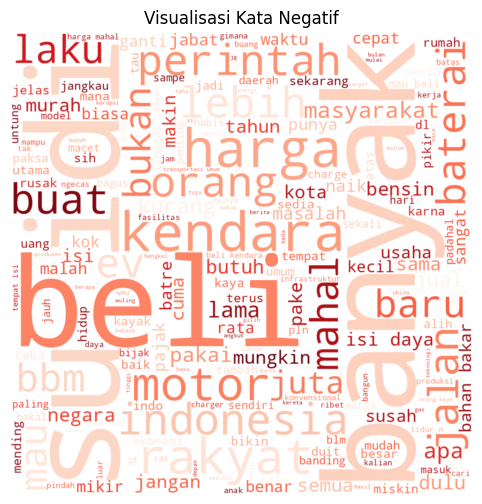

In [21]:
all_text_s0 = ' '.join(word for word in data_negatif["text_cleaning"])
wordcloud = WordCloud(colormap='Reds', width=1000, height=1000, mode='RGBA', background_color='white').generate(all_text_s0)
plt.figure(figsize=(9,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Visualisasi Kata Negatif")
plt.margins(x=0, y=0)
plt.show()

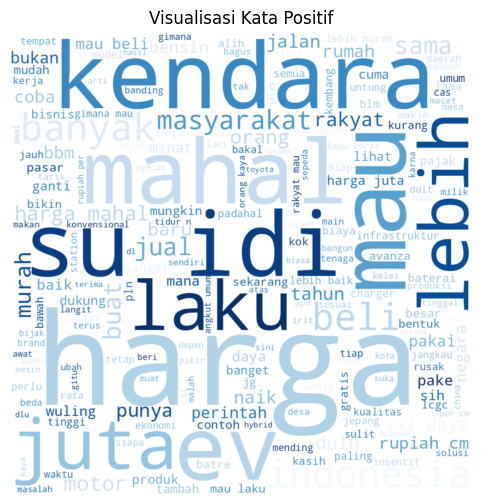

In [22]:
all_text_s1 = ' '.join(word for word in data_positif["text_cleaning"])
wordcloud = WordCloud(colormap='Blues', width=1000, height=1000, mode='RGBA', background_color='white').generate(all_text_s1)
plt.figure(figsize=(9,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Visualisasi Kata Positif")
plt.margins(x=0, y=0)
plt.show()

In [23]:
data_clean['sentimen'].value_counts()

,count
sentimen,
0,868
1,503


In [24]:
data_clean.head()

,text_cleaning,sentimen
0,saran sih bikin harga ionic sama kayak brio in...,1
1,masalah su idi kualitas tidur nin harga dinaik...,0
2,baik kualitas kembang dulu baik kualitas motor...,1
3,model jelek kualitas buruk harga mahal banget,0
4,syarat sembarang woy anak muda punya rumah jd ...,0


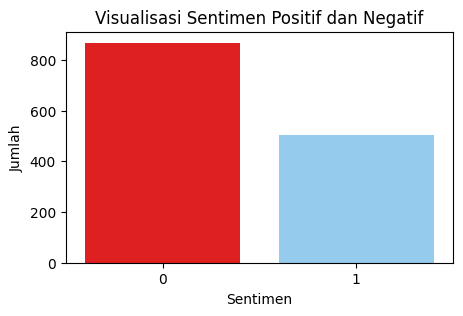

In [25]:
#Visualisasi sentimen positif dan negatif

plt.figure(figsize=(5,3))
sns.countplot(data=data_clean, x='sentimen', hue='sentimen', palette={0: "red", 1: "lightskyblue"}, legend=False)
plt.title("Visualisasi Sentimen Positif dan Negatif")
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')
plt.show()

##4.  Data Preparation

In [26]:
#memisahkan data menjadi data latih dan data uji
X = data_clean['text_cleaning']
y = data_clean['sentimen']
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.15, random_state=42)

In [27]:
#Menggunakan CountVectorizer untuk mengubah teks menjadi fitur numerik
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_train_vec = vectorizer.transform(X_test)

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE

# 1. Split data (Sudah benar)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# 2. Vectorization (Pastikan fit_transform hanya ke X_train)
tfidf = TfidfVectorizer()
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test) # Transform X_test using the fitted vectorizer

# 3. Cek ukuran sebelum SMOTE (Penting untuk debugging)
print(f"Ukuran X_train_vec: {X_train_vec.shape}") # Harus (1165, jumlah_fitur)
print(f"Ukuran y_train: {y_train.shape}")         # Harus (1165,)

# 4. Baru lakukan SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_vec, y_train)

Ukuran X_train_vec: (1165, 3281)
Ukuran y_train: (1165,)


In [29]:
#Melakukan oversampling menggunakan SMOTE pada data latih
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_vec, y_train)

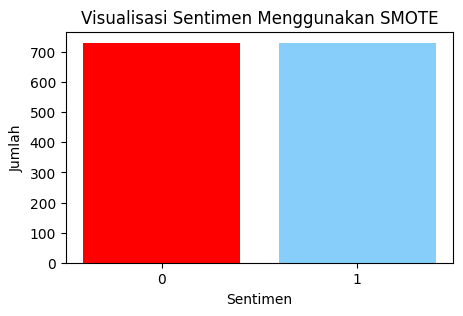

In [30]:
## data sampling agar data sesuai

sentiment_counts = y_train_resampled.value_counts()

plt.figure(figsize=(5,3))
plt.bar(sentiment_counts.index, sentiment_counts.values, color=['red', 'lightskyblue'])
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')
plt.title('Visualisasi Sentimen Menggunakan SMOTE')
plt.xticks(sentiment_counts.index, ['0', '1'])
plt.show()

## 5. MODELING

In [31]:
naive_bayes = MultinomialNB()
naive_bayes.fit(X_train_resampled, y_train_resampled)

MultinomialNB()

In [32]:
X_test_vec = tfidf.transform(X_test)

In [33]:
y_pred = naive_bayes.predict(X_test_vec)

In [34]:
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred, target_names=['negatif', 'positif'])

print("Akurasi Model Naive Bayes : ", accuracy)
print("\nLaporan Klasifikasi : \n", classification_rep)

Akurasi Model Naive Bayes :  0.7766990291262136

Laporan Klasifikasi : 
               precision    recall  f1-score   support

     negatif       0.85      0.81      0.83       137
     positif       0.65      0.71      0.68        69

    accuracy                           0.78       206
   macro avg       0.75      0.76      0.75       206
weighted avg       0.78      0.78      0.78       206



## 6. Testing

In [38]:
new_text = input("\n Masukan teks baru : ")
new_text_vec = vectorizer.transform([new_text])
predicted_sentimen = naive_bayes.predict(new_text_vec)

if predicted_sentimen[0] == 1:
  sentiment_label = "positif"
elif predicted_sentimen[0] == 0:
  sentiment_label = "negatif"

print("Hasil Analisis Sentimen untuk Teks Baru :", sentiment_label)


 Masukan teks baru : Akselerasi mobil listrik ternyata instan banget, gak nyangka tarikannya sehalus ini.
Hasil Analisis Sentimen untuk Teks Baru : positif
